In [100]:
import importlib
import own_implementation
importlib.reload(own_implementation)

<module 'own_implementation' from 'C:\\Users\\szymo\\PycharmProjects\\PRNG-Testt\\own_implementation.py'>

In [101]:
# from own_implementation import *
from tests import *
from generators import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
from scipy import stats
from scipy.stats import chi2_contingency, kstest 
from statsmodels.tsa.stattools import acf 
from statsmodels.sandbox.stats.runs import runstest_1samp

In [102]:
# def python_random(n):
#     return [random.random() for _ in range(n)]
#
# def PCG(n):
#     rng = np.random.default_rng()
#     return rng.uniform(0, 1, n)
#
# def system_random(n):
#     sys_random = random.SystemRandom()
#     return [sys_random.random() for _ in range(n)]


In [103]:
from generators import *
from numpy.random import Generator, PCG64, MT19937, Philox, SFC64
from scipy.stats import norm

# def lcg_random_seed():
#
#     return int(time.time() * 1000) % (2**32)

### Generators preparation
n = 10000

generators = {
    "LCG": lambda: LCG(1664525, 1013904223, 2**32, n=n),
    "Python Random(MT)": lambda: python_random(n=n), ## Python's built-in random module (Mersenne Twister)
    "System Random": lambda: system_random(n=n), ## System's random module (kryptographic)
    "PCG": lambda: numpy_random(n=n),   ## Numpy's default random module (PCG64),
    "Philox": lambda: numpy_random(n=n, algorithm=Philox),
    "SFC64": lambda: numpy_random(n=n, algorithm=SFC64),  ## Numpy's Philox generator
    "xorshift": lambda: xorshift(n=n, seed=None),  ## Custom xorshift generator
    "Normal (Gauss)": lambda: np.random.normal(loc=0, scale=1, size=n)
}

data_samples = {name: gen() for name, gen in generators.items()}
for name, data in data_samples.items():
    print(f"{name}: wygenerowane {len(data)} liczb losowych")


LCG: wygenerowane 10000 liczb losowych
Python Random(MT): wygenerowane 10000 liczb losowych
System Random: wygenerowane 10000 liczb losowych
PCG: wygenerowane 10000 liczb losowych
Philox: wygenerowane 10000 liczb losowych
SFC64: wygenerowane 10000 liczb losowych
xorshift: wygenerowane 10000 liczb losowych
Normal (Gauss): wygenerowane 10000 liczb losowych


In [104]:
### Autocorrelation
# max_lag = 20

# for name,data in data_samples.items():
#     autocorr = acf(data, nlags=max_lag, fft=True)

#     plt.figure(figsize=(8, 4))
#     plt.bar(range(1, max_lag+1), autocorr[1:], color='navy', edgecolor='black')
#     plt.axhline(0, color='red', linestyle='--')
#     plt.title(f'Autocorrelation for {name}')
#     plt.xlabel('Lag')
#     plt.ylabel('Autocorrelation')
#     plt.xticks(range(1, max_lag+1))
#     plt.grid()  
#     plt.show()
    

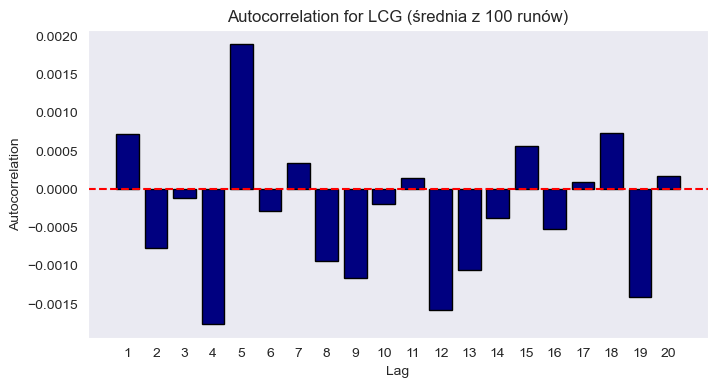

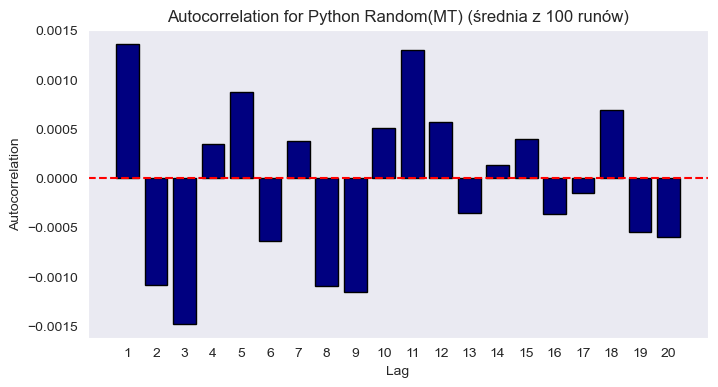

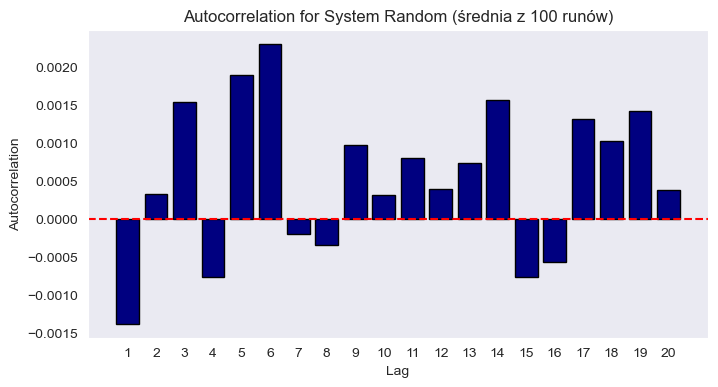

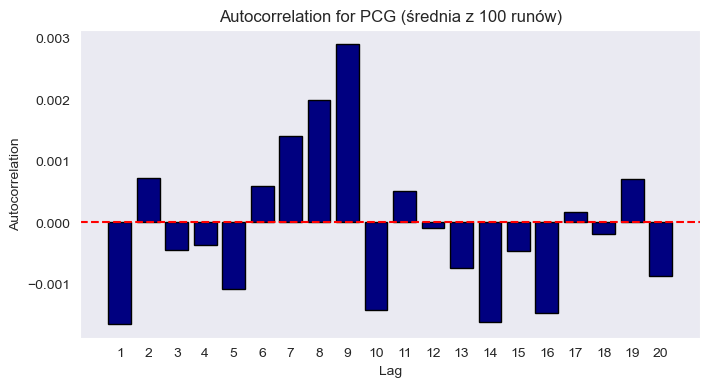

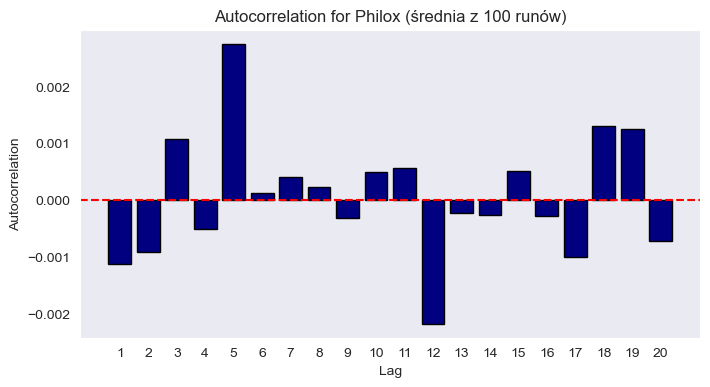

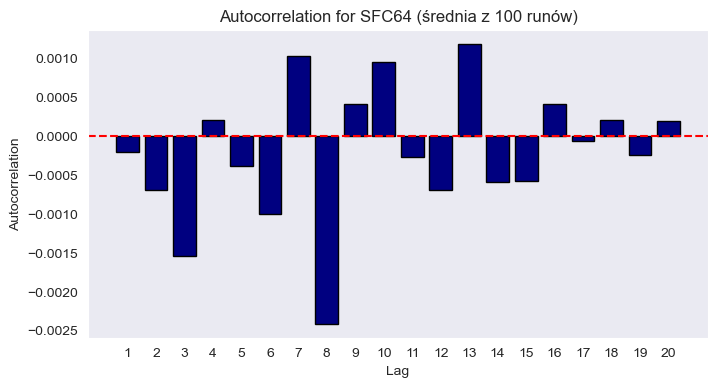

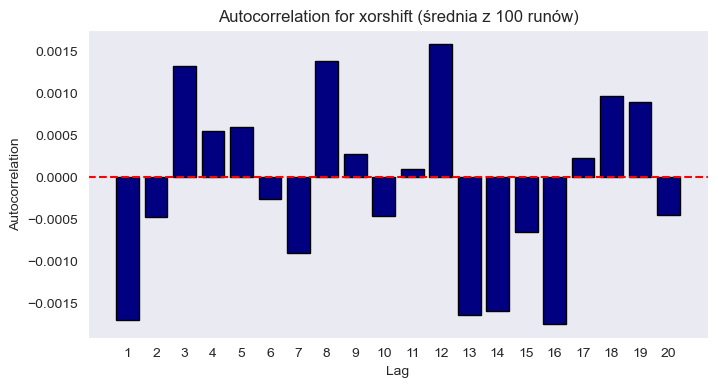

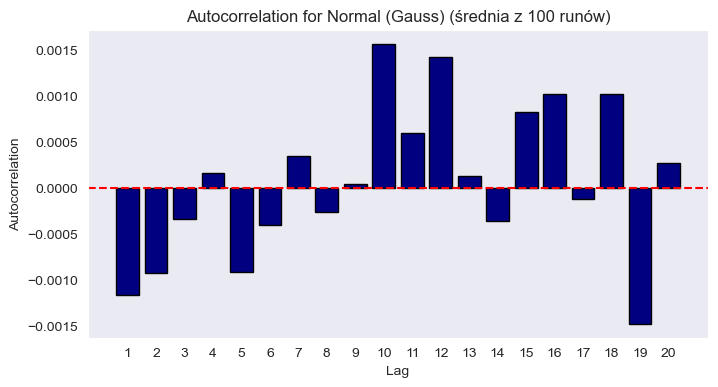

In [105]:
max_lag = 20
n_runs = 100

for name, gen in generators.items():
    all_autocorrs = []
    for _ in range(n_runs):
        data = gen()
        autocorr = acf(data, nlags=max_lag, fft=True)
        all_autocorrs.append(autocorr)
    all_autocorrs = np.array(all_autocorrs)
    mean_autocorr = np.mean(all_autocorrs, axis=0)

    plt.figure(figsize=(8, 4))
    plt.bar(range(1, max_lag+1), mean_autocorr[1:], color='navy', edgecolor='black')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Autocorrelation for {name} (średnia z {n_runs} runów)')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.xticks(range(1, max_lag+1))
    plt.grid()
    plt.show()

In [106]:
### Chi Square Test
# bins = 20
# alpha = 0.05
# fig, axes = plt.subplots(3, 2, figsize=(12, 10))
# axes = axes.flatten()

# for idx, (name, data) in enumerate(data_samples.items()):
#     chi2_stat, p_val = chi_square_test(data, bins=bins)
#     result = "Zdał test" if p_val > alpha else "Nie zdał testu"

#     axes[idx].hist(data, bins=bins, edgecolor='black', color='skyblue')
#     axes[idx].set_title(f"{name} Chi = {chi2_stat:.2f}, p = {p_val:.3f}, alfa = {alpha}, {result}")
#     axes[idx].set_xlabel("Wartości")
#     axes[idx].set_ylabel("Częstość")

# plt.tight_layout()
# plt.suptitle("Test Chi-kwadrat dla różnych generatorów liczb losowych", fontsize=16, y=1.02)
# plt.show()

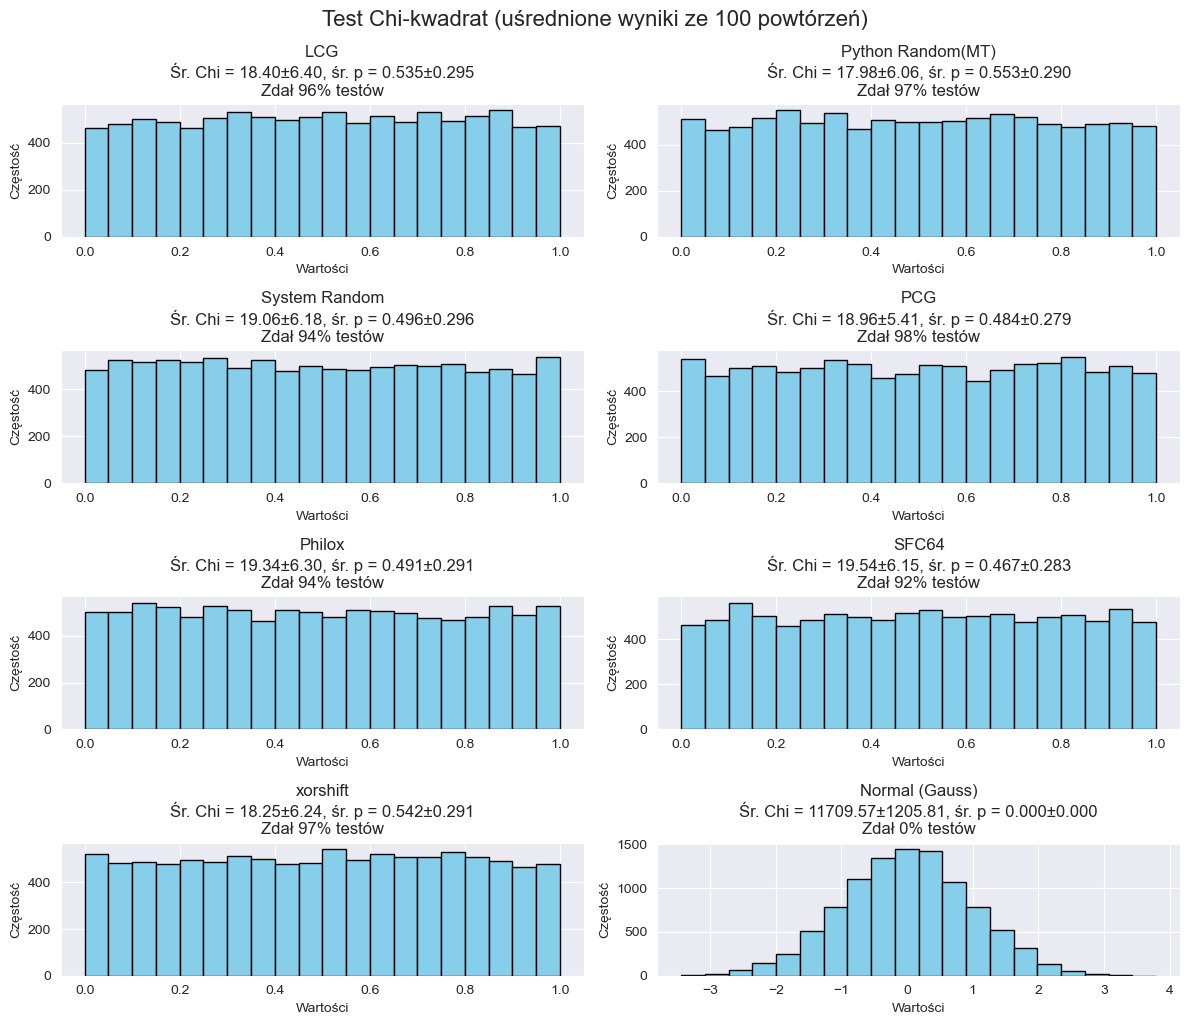

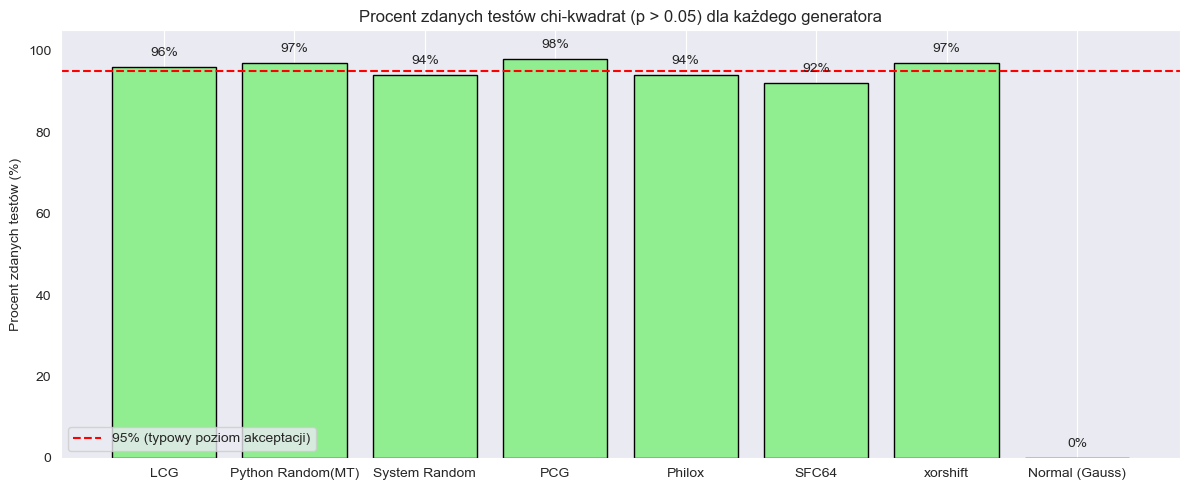

In [126]:
## Test Chi2 dla 100 runów
bins = 20
alpha = 0.05
n_runs = 100

mean_chi2_stats = {}
mean_chi2_pvals = {}
std_chi2_stats = {}
std_chi2_pvals = {}
pass_percent = {}

all_chi2_stats = {}
all_chi2_pvals = {}

for name, gen in generators.items():
    chi2_stats = []
    chi2_pvals = []
    passed = 0
    for _ in range(n_runs):
        data = gen()
        chi2_stat, p_val = chi_square_test(data, bins=bins)
        chi2_stats.append(chi2_stat)
        chi2_pvals.append(p_val)
        if p_val > alpha:
            passed += 1
    mean_chi2_stats[name] = np.mean(chi2_stats)
    mean_chi2_pvals[name] = np.mean(chi2_pvals)
    std_chi2_stats[name] = np.std(chi2_stats)
    std_chi2_pvals[name] = np.std(chi2_pvals)
    pass_percent[name] = 100 * passed / n_runs
    all_chi2_stats[name] = chi2_stats
    all_chi2_pvals[name] = chi2_pvals

# Wykres histogramu z jednego runu + statystyki uśrednione
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, name in enumerate(generators.keys()):
    mean_stat = mean_chi2_stats[name]
    mean_p = mean_chi2_pvals[name]
    std_stat = std_chi2_stats[name]
    std_p = std_chi2_pvals[name]
    percent = pass_percent[name]
    result = f"Zdał {percent:.0f}% testów"

    # Histogram z pierwszego runu
    sample_data = generators[name]()
    axes[idx].hist(sample_data, bins=bins, edgecolor='black', color='skyblue')
    axes[idx].set_title(f"{name}\nŚr. Chi = {mean_stat:.2f}±{std_stat:.2f}, śr. p = {mean_p:.3f}±{std_p:.3f}\n{result}")
    axes[idx].set_xlabel("Wartości")
    axes[idx].set_ylabel("Częstość")

plt.tight_layout()
plt.suptitle("Test Chi-kwadrat (uśrednione wyniki ze 100 powtórzeń)", fontsize=16, y=1.02)
plt.show()

# Wykres procentu zdanych testów
plt.figure(figsize=(12, 5))
names = list(generators.keys())
percents = [pass_percent[n] for n in names]
bars = plt.bar(names, percents, color='lightgreen', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, percents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów chi-kwadrat (p > 0.05) dla każdego generatora")
plt.grid(axis='y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [108]:
## Kolmogorov-Smirnov Test
# alpha = 0.05

# for name, data in data_samples.items():
#     ks_stat, p_val = ks_test(data)
#     result = "Zdał test" if p_val > alpha else "Nie zdał testu"

#     sorted_data = np.sort(data)
#     ecdf = np.arange(1, len(data) + 1) / len(data)
#     cdf = sorted_data  

#     plt.figure(figsize=(6,4))
#     plt.plot(sorted_data, ecdf, label='Empiryczna CDF', color='blue')
#     plt.plot(sorted_data, cdf, label='Teoretyczna CDF', linestyle='--', color='red')
#     plt.title(f"{name}\nKS stat = {ks_stat:.4f}, p = {p_val:.3f}\n{result}")
#     plt.xlabel("Wartości")
#     plt.ylabel("CDF")
#     plt.legend()
#     plt.grid(True)
#     plt.show()


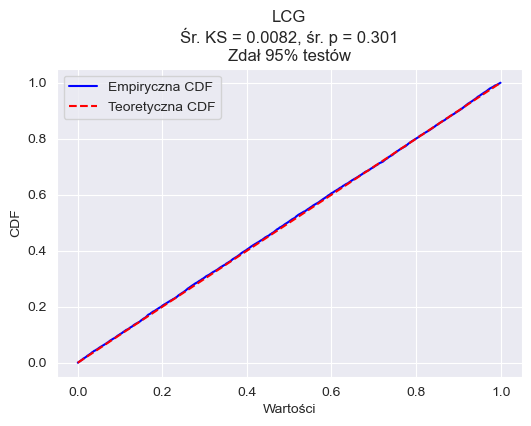

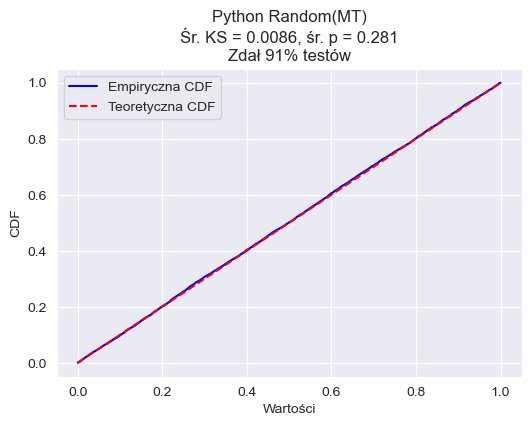

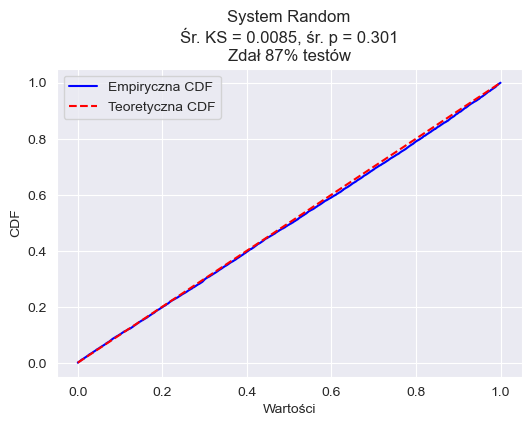

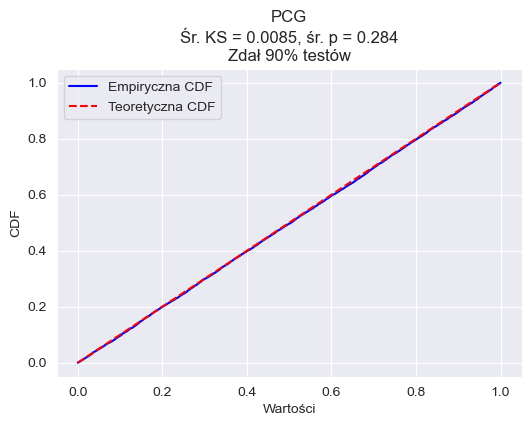

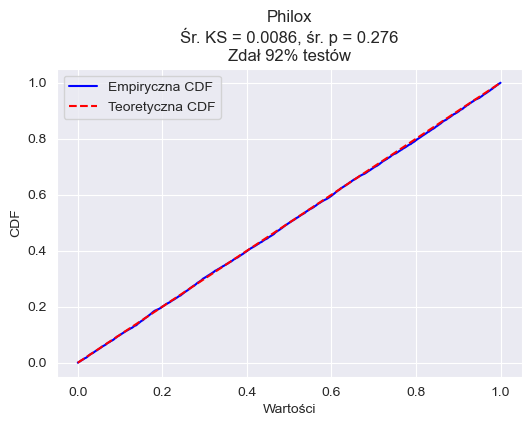

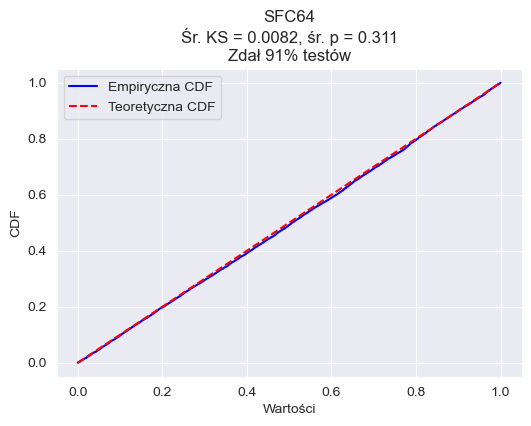

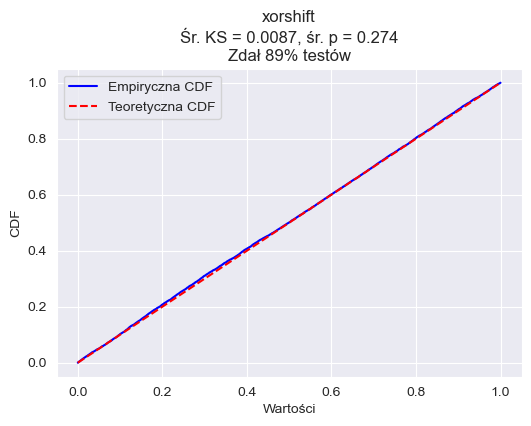

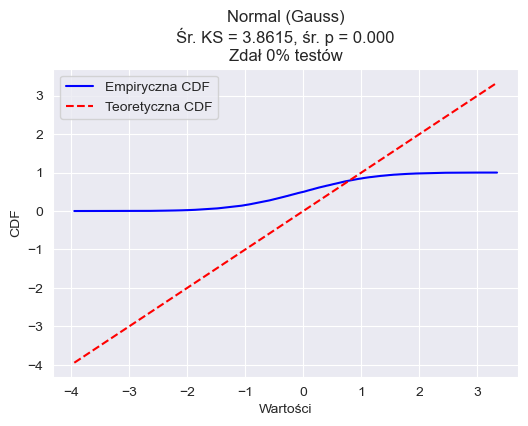

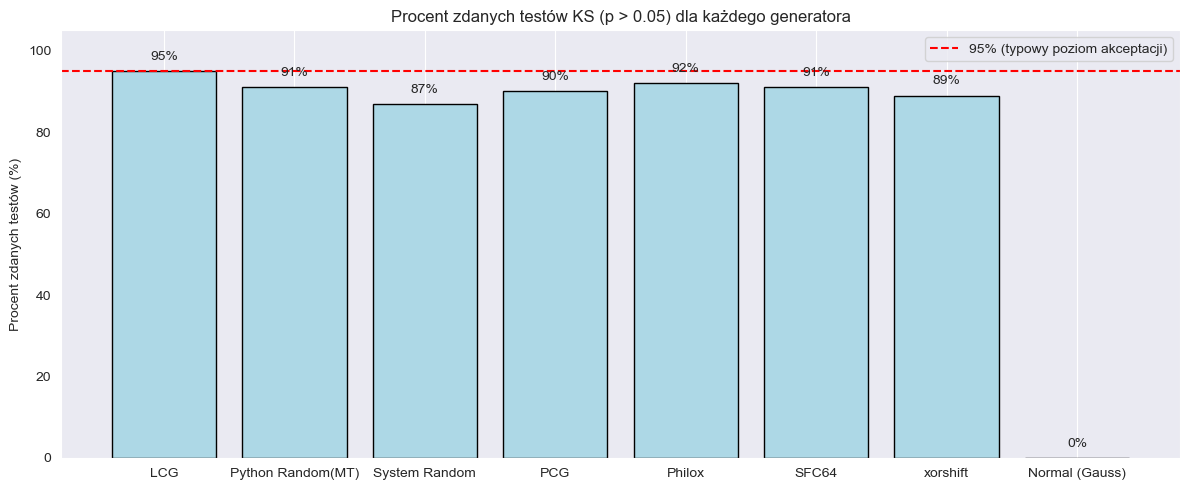

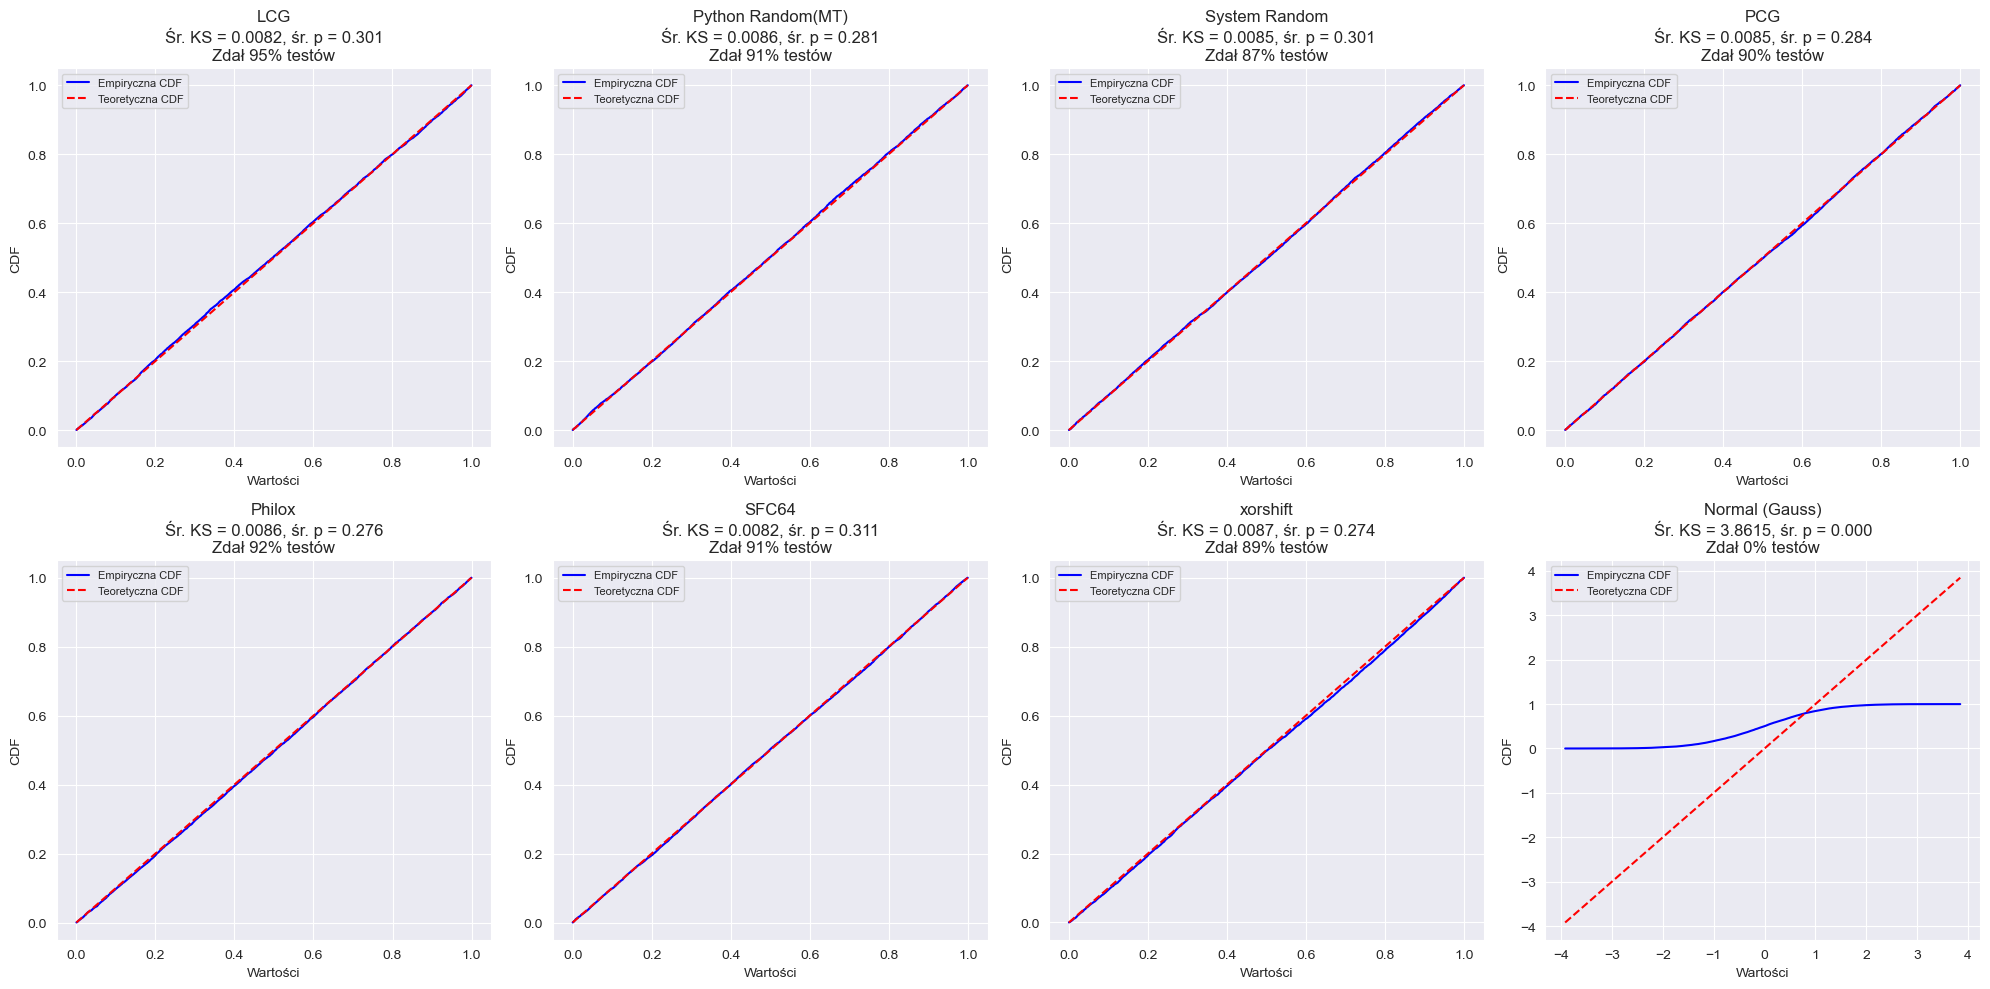

In [131]:
## Test KS dla 100 runów
alpha = 0.05
n_runs = 100

mean_ks_stats = {}
mean_ks_pvals = {}
std_ks_stats = {}
std_ks_pvals = {}
pass_percent_ks = {}

for name, gen in generators.items():
    ks_stats = []
    ks_pvals = []
    passed = 0
    for _ in range(n_runs):
        data = gen()
        ks_stat, p_val = ks_test(data)
        ks_stats.append(ks_stat)
        ks_pvals.append(p_val)
        if p_val > alpha:
            passed += 1
    mean_ks_stats[name] = np.mean(ks_stats)
    mean_ks_pvals[name] = np.mean(ks_pvals)
    std_ks_stats[name] = np.std(ks_stats)
    std_ks_pvals[name] = np.std(ks_pvals)
    pass_percent_ks[name] = 100 * passed / n_runs

for name, gen in generators.items():
    data = gen()
    ks_stat = mean_ks_stats[name]
    p_val = mean_ks_pvals[name]
    percent = pass_percent_ks[name]
    result = f"Zdał {percent:.0f}% testów"

    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data) + 1) / len(data)
    cdf = sorted_data

    plt.figure(figsize=(6,4))
    plt.plot(sorted_data, ecdf, label='Empiryczna CDF', color='blue')
    plt.plot(sorted_data, cdf, label='Teoretyczna CDF', linestyle='--', color='red')
    plt.title(f"{name}\nŚr. KS = {ks_stat:.4f}, śr. p = {p_val:.3f}\n{result}")
    plt.xlabel("Wartości")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True)
    plt.show()


plt.figure(figsize=(12, 5))
names = list(generators.keys())
percents = [pass_percent_ks[n] for n in names]
bars = plt.bar(names, percents, color='lightblue', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, percents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów KS (p > 0.05) dla każdego generatora")
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, gen) in enumerate(generators.items()):
    data = gen()
    ks_stat = mean_ks_stats[name]
    p_val = mean_ks_pvals[name]
    percent = pass_percent_ks[name]
    result = f"Zdał {percent:.0f}% testów"

    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data) + 1) / len(data)
    cdf = sorted_data

    ax = axes[idx]
    ax.plot(sorted_data, ecdf, label='Empiryczna CDF', color='blue')
    ax.plot(sorted_data, cdf, label='Teoretyczna CDF', linestyle='--', color='red')
    ax.set_title(f"{name}\nŚr. KS = {ks_stat:.4f}, śr. p = {p_val:.3f}\n{result}")
    ax.set_xlabel("Wartości")
    ax.set_ylabel("CDF")
    ax.grid(True)
    ax.legend(fontsize=8)


plt.tight_layout()
plt.show()

In [110]:
## Sum test
# alpha = 0.05

# for name,data in data_samples.items():
#     z_stat, p_val = sum_test(data)
#     result = "Zdał test" if p_val > alpha else "Nie zdał testu"

#     plt.figure(figsize=(6,4))
#     plt.hist(data, bins=50, edgecolor='black', color='lightgreen')
#     plt.axvline(0.5, color='red', linestyle='--', label='Oczekiwana wartość 0.5')
#     plt.title(f"{name}\nZ = {z_stat:.2f}, p = {p_val:.3f}\n{result}")
#     plt.xlabel("Wartości")
#     plt.ylabel("Liczność")
#     plt.legend()
#     plt.grid(True)
#     plt.show()


# expected_var = 1 / 12 

# variances = {name: np.var(data) for name, data in data_samples.items()}

# plt.figure(figsize=(8, 5))
# bars = plt.bar(variances.keys(), variances.values(), color='skyblue', edgecolor='black')
# plt.axhline(expected_var, color='red', linestyle='--', label=f"Oczekiwana wariancja = {expected_var:.4f}")

# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{yval:.4f}", ha='center', va='bottom', fontsize=9)

# plt.title("Wariancja danych dla różnych generatorów")
# plt.ylabel("Wariancja")
# plt.legend()
# plt.grid(axis='y')
# plt.tight_layout()
# plt.show()

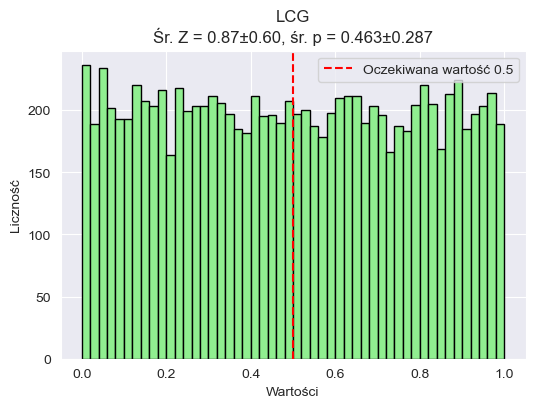

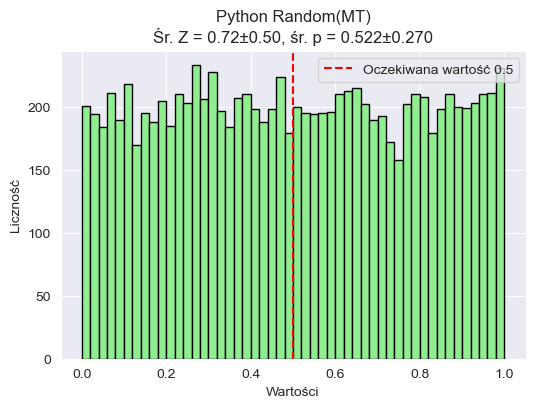

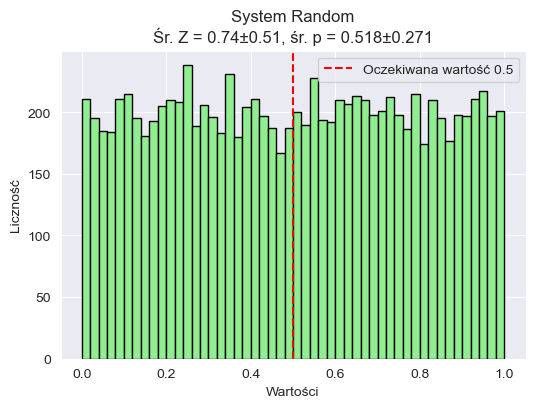

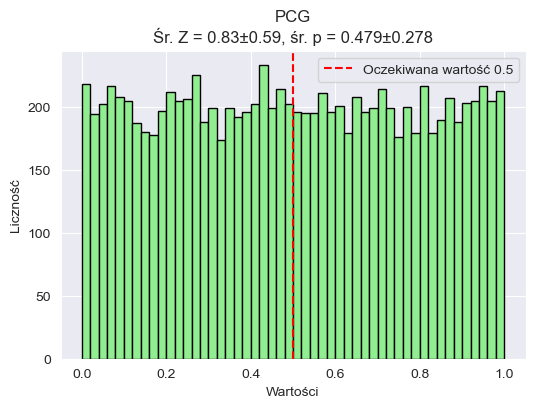

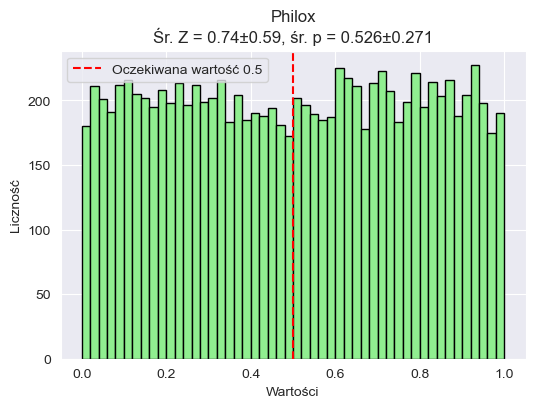

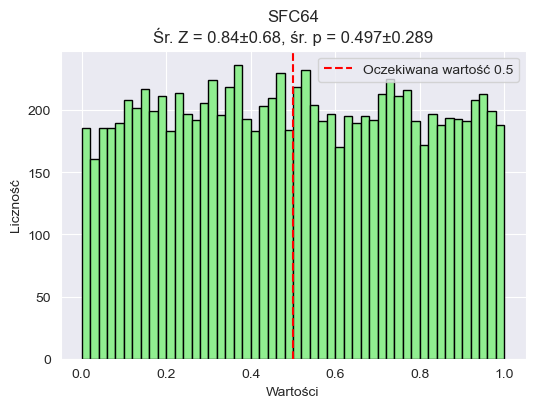

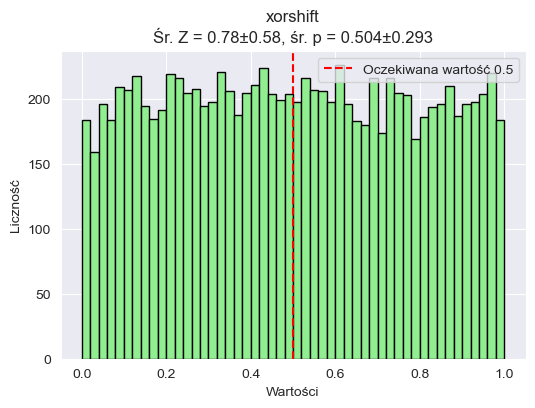

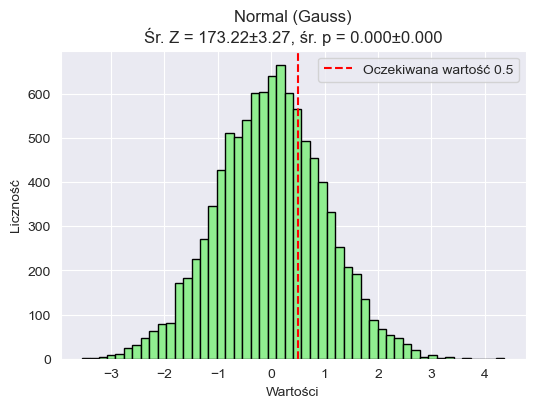

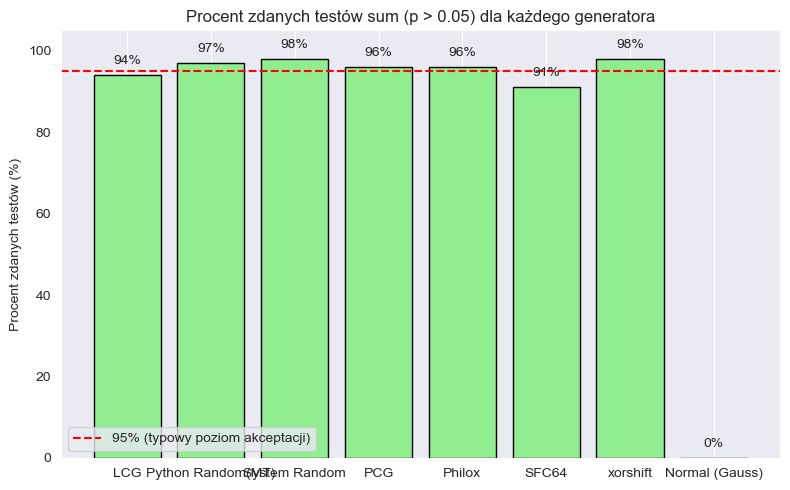

In [132]:
## Test Sum dla 100 runów
alpha = 0.05
n_runs = 100

mean_z_stats = {}
mean_pvals = {}
std_z_stats = {}
std_pvals = {}
pass_percent_sum = {}

for name, gen in generators.items():
    z_stats = []
    pvals = []
    passed = 0
    all_data = []
    for _ in range(n_runs):
        data = gen()
        z_stat, p_val = sum_test(data)
        z_stats.append(z_stat)
        pvals.append(p_val)
        all_data.append(data)
        if p_val > alpha:
            passed += 1
    mean_z_stats[name] = np.mean(z_stats)
    mean_pvals[name] = np.mean(pvals)
    std_z_stats[name] = np.std(z_stats)
    std_pvals[name] = np.std(pvals)
    pass_percent_sum[name] = 100 * passed / n_runs

    # Histogram z pierwszego runu
    plt.figure(figsize=(6,4))
    plt.hist(all_data[0], bins=50, edgecolor='black', color='lightgreen')
    plt.axvline(0.5, color='red', linestyle='--', label='Oczekiwana wartość 0.5')
    plt.title(f"{name}\nŚr. Z = {mean_z_stats[name]:.2f}±{std_z_stats[name]:.2f}, śr. p = {mean_pvals[name]:.3f}±{std_pvals[name]:.3f}")
    plt.xlabel("Wartości")
    plt.ylabel("Liczność")
    plt.legend()
    plt.grid(True)
    plt.show()

plt.figure(figsize=(8, 5))
names = list(generators.keys())
percents = [pass_percent_sum[n] for n in names]
bars = plt.bar(names, percents, color='lightgreen', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, percents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów sum (p > 0.05) dla każdego generatora")
plt.grid(axis='y')
plt.legend(loc='lower left')
# plt.legend()
plt.tight_layout()
plt.show()

In [112]:
# D2 test
# alpha = 0.05

# for name, data in data_samples.items():
#     d2_stat, p_val = d2_test(data)
#     result = "Zdał test" if p_val > alpha else "Nie zdał testu"

#     x = data[::2]
#     y = data[1::2]

#     plt.figure(figsize=(6,6))
#     plt.scatter(x, y, s=5, alpha=0.5)
#     plt.title(f"{name}\nD² = {d2_stat:.4f}, p = {p_val:.3f}\n{result}")
#     plt.xlabel("x")
#     plt.ylabel("y")
#     plt.grid(True)
#     plt.gca().set_aspect('equal')
#     plt.show()

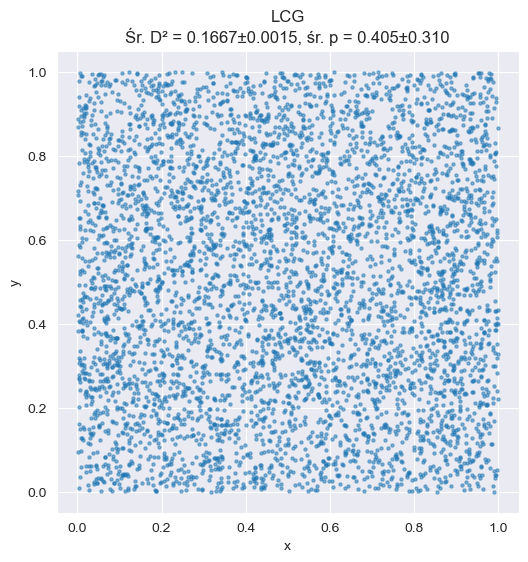

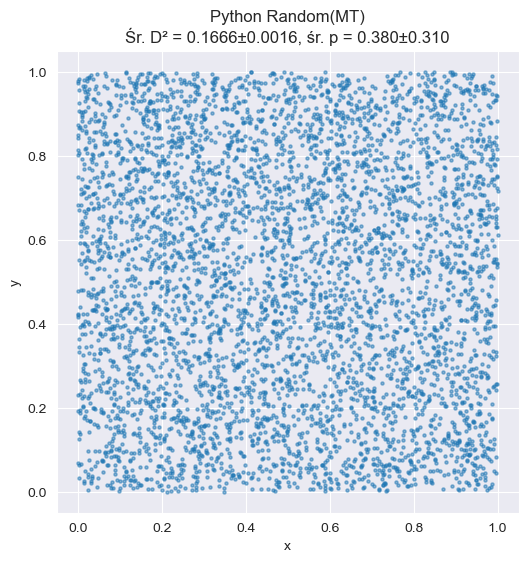

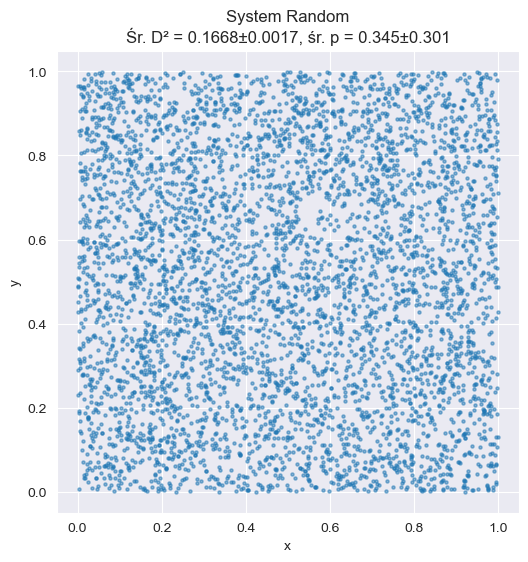

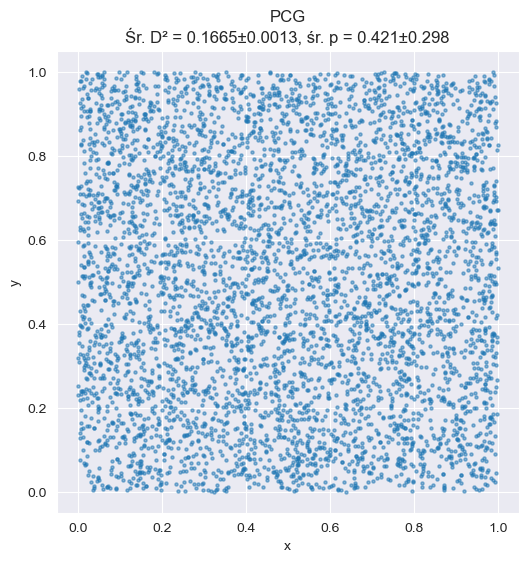

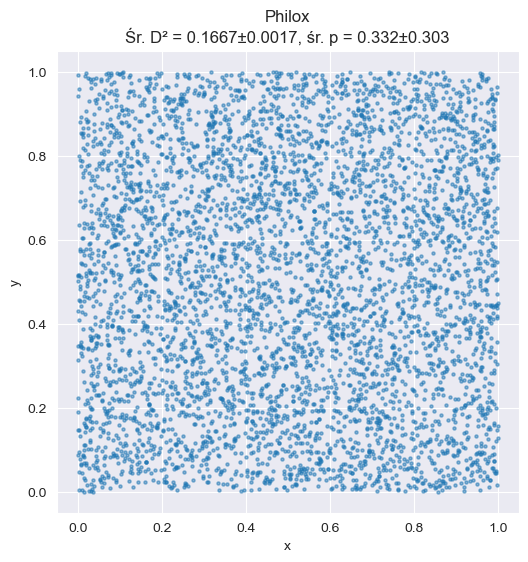

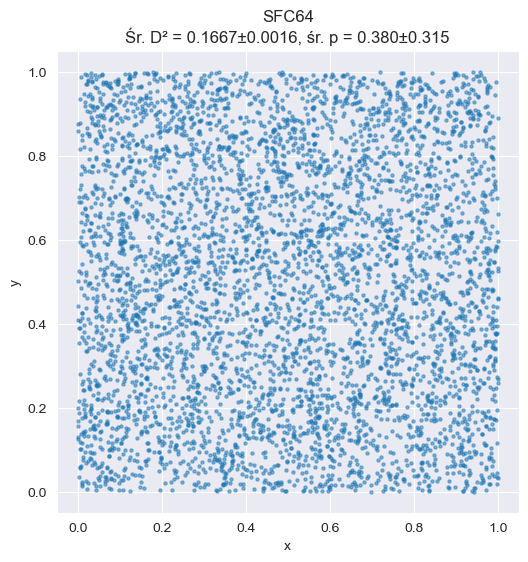

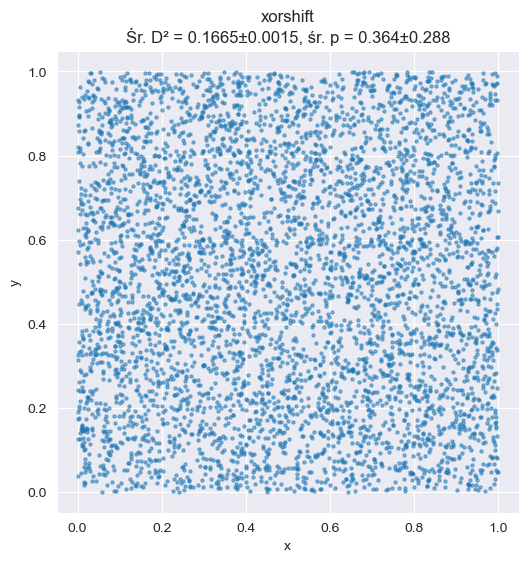

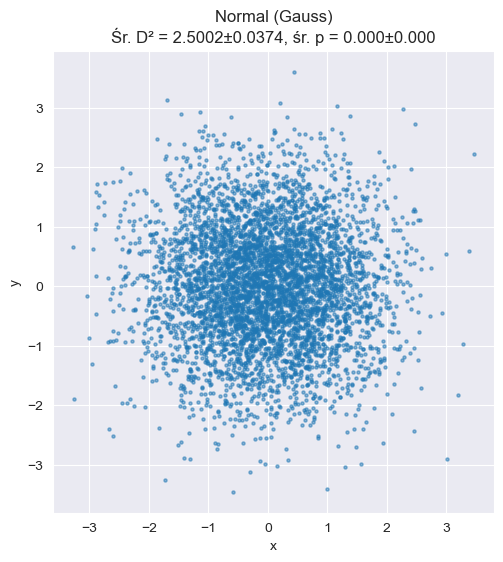

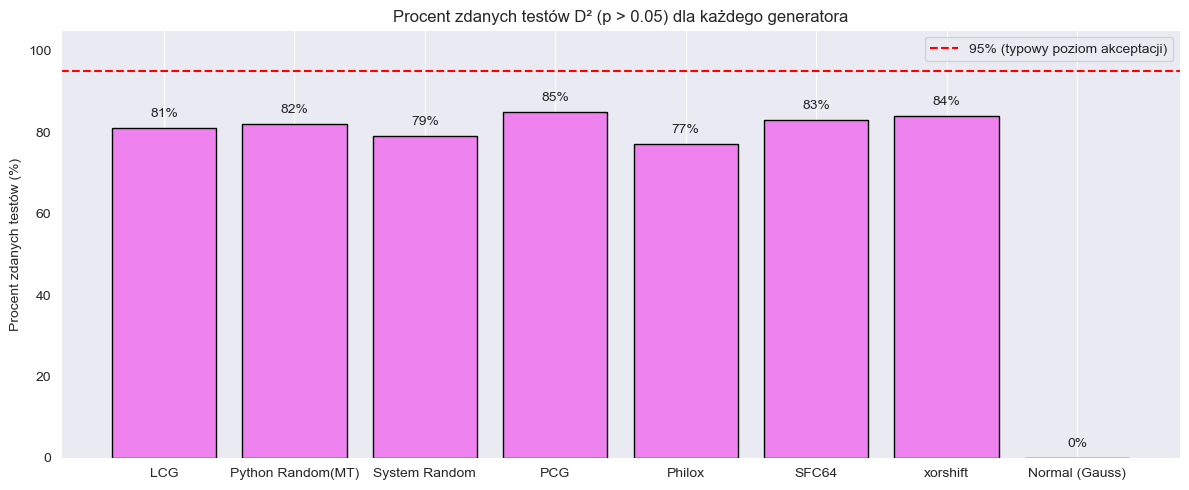

In [134]:
## Test D2 dla 100 runów
alpha = 0.05
n_runs = 100

mean_d2_stats = {}
mean_pvals_d2 = {}
std_d2_stats = {}
std_pvals_d2 = {}
pass_percent_d2 = {}

for name, gen in generators.items():
    d2_stats = []
    pvals = []
    passed = 0
    all_data = []
    for _ in range(n_runs):
        data = gen()
        d2_stat, p_val = d2_test(data)
        d2_stats.append(d2_stat)
        pvals.append(p_val)
        all_data.append(data)
        if p_val > alpha:
            passed += 1
    mean_d2_stats[name] = np.mean(d2_stats)
    mean_pvals_d2[name] = np.mean(pvals)
    std_d2_stats[name] = np.std(d2_stats)
    std_pvals_d2[name] = np.std(pvals)
    pass_percent_d2[name] = 100 * passed / n_runs

    # Scatter plot z pierwszego runu
    x = all_data[0][::2]
    y = all_data[0][1::2]
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, s=5, alpha=0.5)
    plt.title(f"{name}\nŚr. D² = {mean_d2_stats[name]:.4f}±{std_d2_stats[name]:.4f}, śr. p = {mean_pvals_d2[name]:.3f}±{std_pvals_d2[name]:.3f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.gca().set_aspect('equal')
    plt.show()

plt.figure(figsize=(12, 5))
names = list(generators.keys())
percents = [pass_percent_d2[n] for n in names]
bars = plt.bar(names, percents, color='violet', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, percents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów D² (p > 0.05) dla każdego generatora")
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

In [114]:
# buckets = 1000


# for name, data in data_samples.items():
#     actual_collisions, expected_collisions = collision_test(data, m=buckets)
#     result = "Zdał test" if actual_collisions <= expected_collisions * 1.1 else "Nie zdał testu"

#     hits = np.zeros(buckets, dtype=int)
#     for x in data:
#         idx = int(x * buckets)
#         if idx == buckets: idx -= 1
#         hits[idx] += 1

#     plt.figure(figsize=(6,4))
#     plt.hist(hits, bins=range(0, max(hits)+2), align='left', color='salmon', edgecolor='black')
#     plt.title(f"{name}\nKolizje = {actual_collisions}, oczekiwane ≈ {expected_collisions:.1f}\n{result}")
#     plt.xlabel("Liczba trafień do kubełka")
#     plt.ylabel("Liczność")
#     plt.grid(True)
#     plt.show()

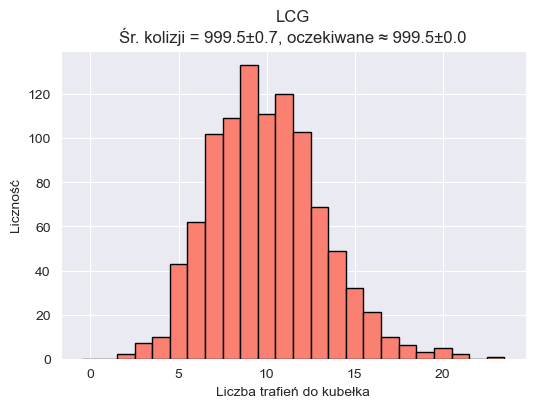

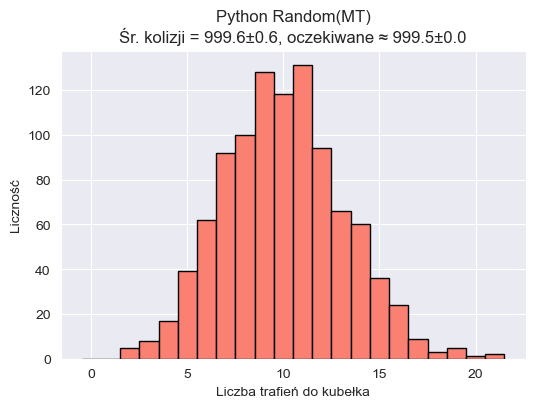

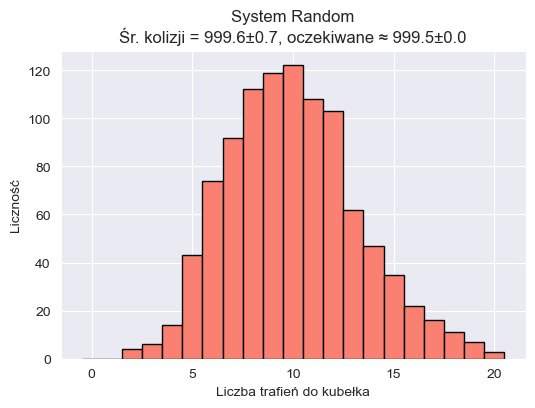

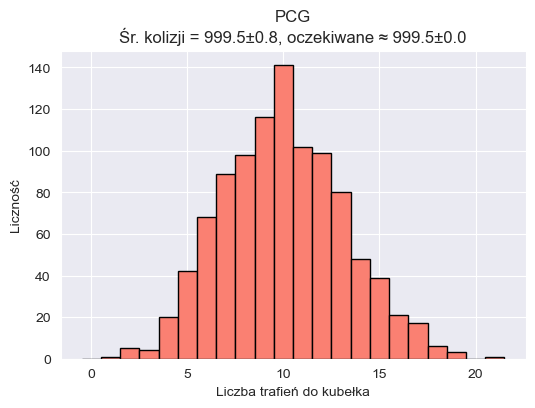

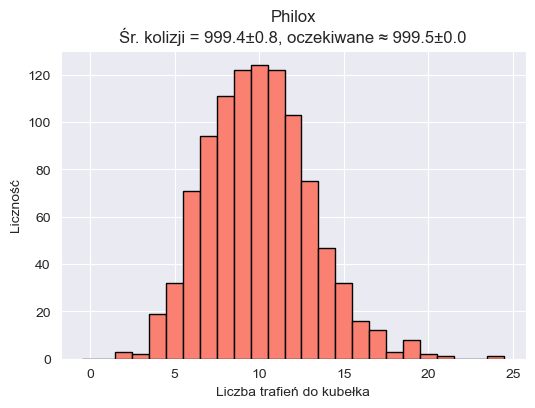

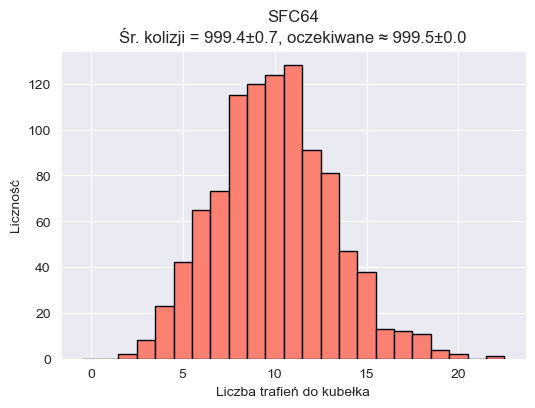

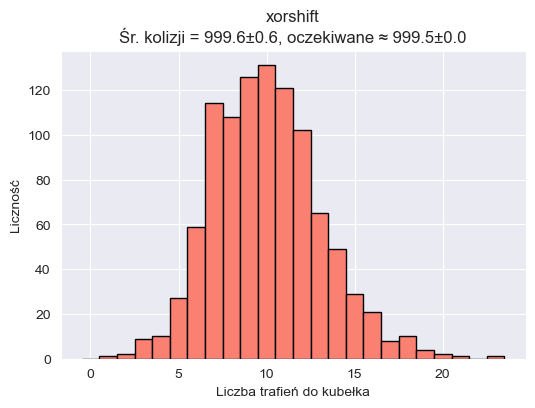

Pominięcie testu kolizji dla 'Normal (Gauss)', ponieważ generuje rozkład normalny, a nie jednostajnego [0,1).


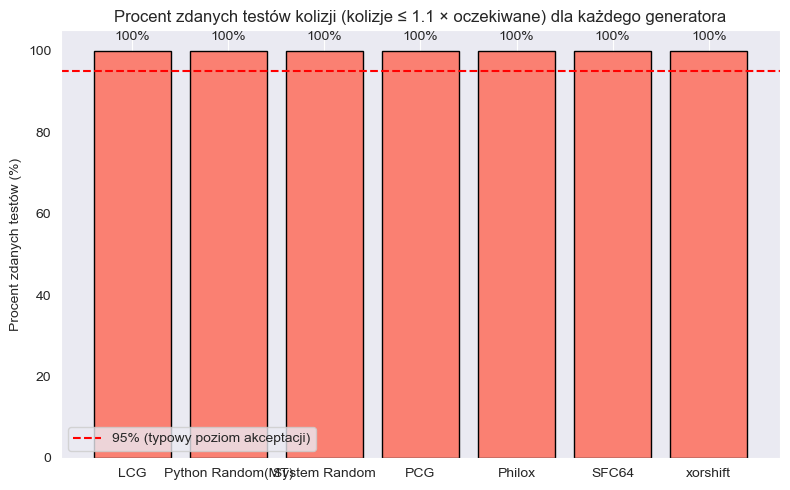

In [135]:
## Test Kolizji dla 100 runów
buckets = 1000
n_runs = 100

mean_actual_collisions = {}
mean_expected_collisions = {}
std_actual_collisions = {}
std_expected_collisions = {}
pass_percent_coll = {}

for name, gen in generators.items():
    if name == "Normal (Gauss)":
        print(f"Pominięcie testu kolizji dla '{name}', ponieważ generuje rozkład normalny, a nie jednostajnego [0,1).")

        continue
    actuals = []
    expecteds = []
    passed = 0
    all_hits = []
    for _ in range(n_runs):
        data = gen()
        actual, expected = collision_test(data, m=buckets)
        actuals.append(actual)
        expecteds.append(expected)
        if actual <= expected * 1.1:
            passed += 1
        # Zapisz hits tylko z pierwszego runu do histogramu
        if len(all_hits) == 0:
            hits = np.zeros(buckets, dtype=int)
            for x in data:
                idx = int(x * buckets)
                if idx == buckets: idx -= 1
                hits[idx] += 1
            all_hits.append(hits)
    mean_actual_collisions[name] = np.mean(actuals)
    mean_expected_collisions[name] = np.mean(expecteds)
    std_actual_collisions[name] = np.std(actuals)
    std_expected_collisions[name] = np.std(expecteds)
    pass_percent_coll[name] = 100 * passed / n_runs

    # Histogram z pierwszego runu
    plt.figure(figsize=(6,4))
    plt.hist(all_hits[0], bins=range(0, max(all_hits[0])+2), align='left', color='salmon', edgecolor='black')
    plt.title(f"{name}\nŚr. kolizji = {mean_actual_collisions[name]:.1f}±{std_actual_collisions[name]:.1f}, oczekiwane ≈ {mean_expected_collisions[name]:.1f}±{std_expected_collisions[name]:.1f}")
    plt.xlabel("Liczba trafień do kubełka")
    plt.ylabel("Liczność")
    plt.grid(True)
    plt.show()

plt.figure(figsize=(8, 5))
names = list(generators.keys())
names_filtered = [n for n in list(generators.keys()) if n in pass_percent_coll]
percents = [pass_percent_coll[n] for n in names_filtered]
bars = plt.bar(names_filtered, percents, color='salmon', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, percents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów kolizji (kolizje ≤ 1.1 × oczekiwane) dla każdego generatora")
plt.grid(axis='y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [116]:
# alpha = 0.05

# results = {}

# for name, data in data_samples.items():
#     z_stat, p_val = runs_test(data)
#     result = "Zdał test" if p_val > alpha else "Nie zdał testu"
#     results[name] = {"z": z_stat, "p": p_val, "result": result}
#     print(f"{name}: Z = {z_stat:.3f}, p = {p_val:.4f} → {result}")

# names = list(results.keys())
# pvals = [results[n]["p"] for n in names]
# colors = ["green" if results[n]["p"] > alpha else "red" for n in names]

# plt.figure(figsize=(8, 5))
# plt.bar(names, pvals, color=colors, edgecolor='black')
# plt.axhline(alpha, color='black', linestyle='--', label=f'alpha = {alpha}')
# plt.title("Test serii (runs test) — p-value dla każdego generatora")
# plt.ylabel("p-value")
# plt.xticks(rotation=15)
# plt.legend()
# plt.grid(True)
# plt.show()

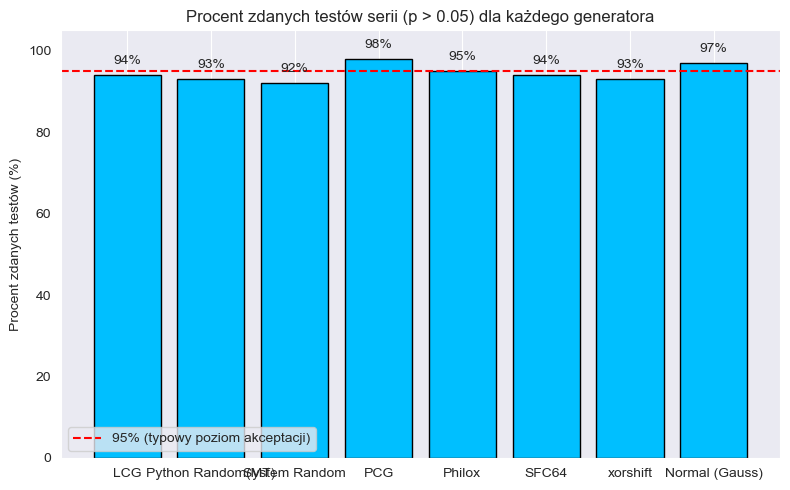

In [117]:
## Test Serii dla 100 runów
alpha = 0.05
n_runs = 100

mean_z_runs = {}
mean_p_runs = {}
std_z_runs = {}
std_p_runs = {}
pass_percent_runs = {}

for name, gen in generators.items():
    z_stats = []
    pvals = []
    passed = 0
    all_data = []
    for _ in range(n_runs):
        data = gen()
        z_stat, p_val = runs_test(data)
        z_stats.append(z_stat)
        pvals.append(p_val)
        all_data.append(data)
        if p_val > alpha:
            passed += 1
    mean_z_runs[name] = np.mean(z_stats)
    mean_p_runs[name] = np.mean(pvals)
    std_z_runs[name] = np.std(z_stats)
    std_p_runs[name] = np.std(pvals)
    pass_percent_runs[name] = 100 * passed / n_runs

plt.figure(figsize=(8, 5))
names = list(generators.keys())
percents = [pass_percent_runs[n] for n in names]
bars = plt.bar(names, percents, color='deepskyblue', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, percents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów serii (p > 0.05) dla każdego generatora")
plt.grid(axis='y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [118]:
# names = []
# actual_runs = []
# expected_runs = []

# for name, data in data_samples.items():
#     median = np.median(data)
#     signs = [1 if x > median else 0 for x in data]

#     runs = 1
#     for i in range(1, len(signs)):
#         if signs[i] != signs[i - 1]:
#             runs += 1

#     n1 = float(np.sum(signs))
#     n2 = float(len(signs) - n1)
#     expected = ((2 * n1 * n2) / (n1 + n2)) + 1

#     names.append(name)
#     actual_runs.append(runs)
#     expected_runs.append(expected)

# # Wykres
# x = np.arange(len(names))
# bar_width = 0.35

# plt.figure(figsize=(10, 5))
# plt.bar(x - bar_width/2, actual_runs, width=bar_width, label="Rzeczywista liczba runów", color='skyblue')
# plt.bar(x + bar_width/2, expected_runs, width=bar_width, label="Oczekiwana liczba runów", color='orange')
# plt.xticks(x, names, rotation=15)
# plt.ylabel("Liczba runów")
# plt.title("Porównanie rzeczywistej i oczekiwanej liczby runów")
# plt.legend()
# plt.grid(True, axis='y')
# plt.tight_layout()
# plt.show()

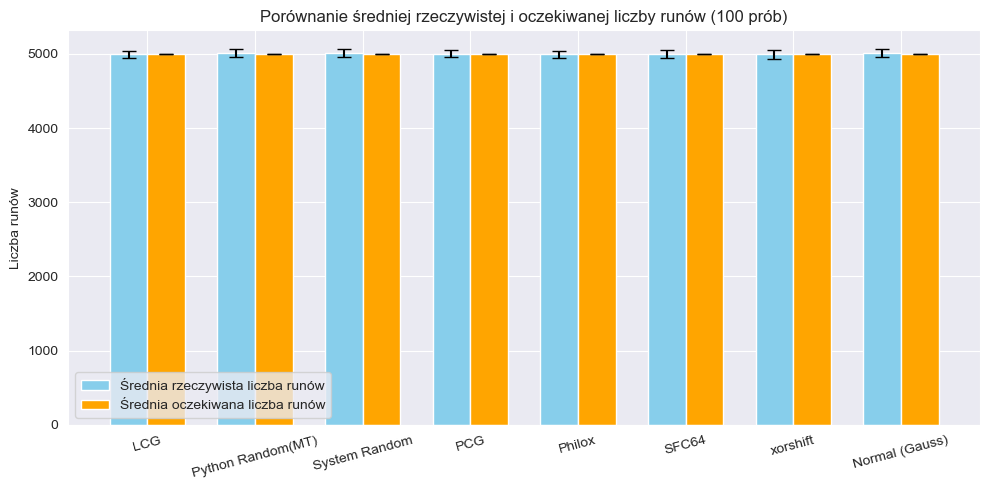

In [119]:
alpha = 0.05
n_runs = 100

mean_actual_runs = {}
mean_expected_runs = {}
std_actual_runs = {}
std_expected_runs = {}

for name, gen in generators.items():
    actual_runs_list = []
    expected_runs_list = []
    for _ in range(n_runs):
        data = gen()
        median = np.median(data)
        signs = [1 if x > median else 0 for x in data]

        runs = 1
        for i in range(1, len(signs)):
            if signs[i] != signs[i - 1]:
                runs += 1

        n1 = float(np.sum(signs))
        n2 = float(len(signs) - n1)
        expected = ((2 * n1 * n2) / (n1 + n2)) + 1

        actual_runs_list.append(runs)
        expected_runs_list.append(expected)
    mean_actual_runs[name] = np.mean(actual_runs_list)
    mean_expected_runs[name] = np.mean(expected_runs_list)
    std_actual_runs[name] = np.std(actual_runs_list)
    std_expected_runs[name] = np.std(expected_runs_list)


names = list(generators.keys())
x = np.arange(len(names))
bar_width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - bar_width/2, [mean_actual_runs[n] for n in names], width=bar_width, 
        yerr=[std_actual_runs[n] for n in names], label="Średnia rzeczywista liczba runów", color='skyblue', capsize=5)
plt.bar(x + bar_width/2, [mean_expected_runs[n] for n in names], width=bar_width, 
        yerr=[std_expected_runs[n] for n in names], label="Średnia oczekiwana liczba runów", color='orange', capsize=5)
plt.xticks(x, names, rotation=15)
plt.ylabel("Liczba runów")
plt.title("Porównanie średniej rzeczywistej i oczekiwanej liczby runów (100 prób)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [120]:

# for name, data in data_samples.items():
#     z_stat, p_val, ones, zeros = monobit_test(data)

#     print(name, f"Z = {z_stat:.3f}, p = {p_val:.4f}")

# plt.figure(figsize=(12, 6))
# index = np.arange(len(generators))

# plt.bar(index-bar_width/2, ones, bar_width, label='1', color='skyblue')
# plt.bar(index+bar_width/2, zeros, bar_width, label='0', color='orange')


# plt.axhline(y=160000, color='red', linestyle='--', linewidth=1, label='Idealny rozkład')

# plt.xlabel('Generator')
# plt.ylabel('Liczba bitów')
# plt.title('Porównanie liczby jedynek i zer w teście monobitowym')
# plt.xticks(index, generators, rotation=45)
# plt.legend()

# plt.tight_layout()
# plt.show()

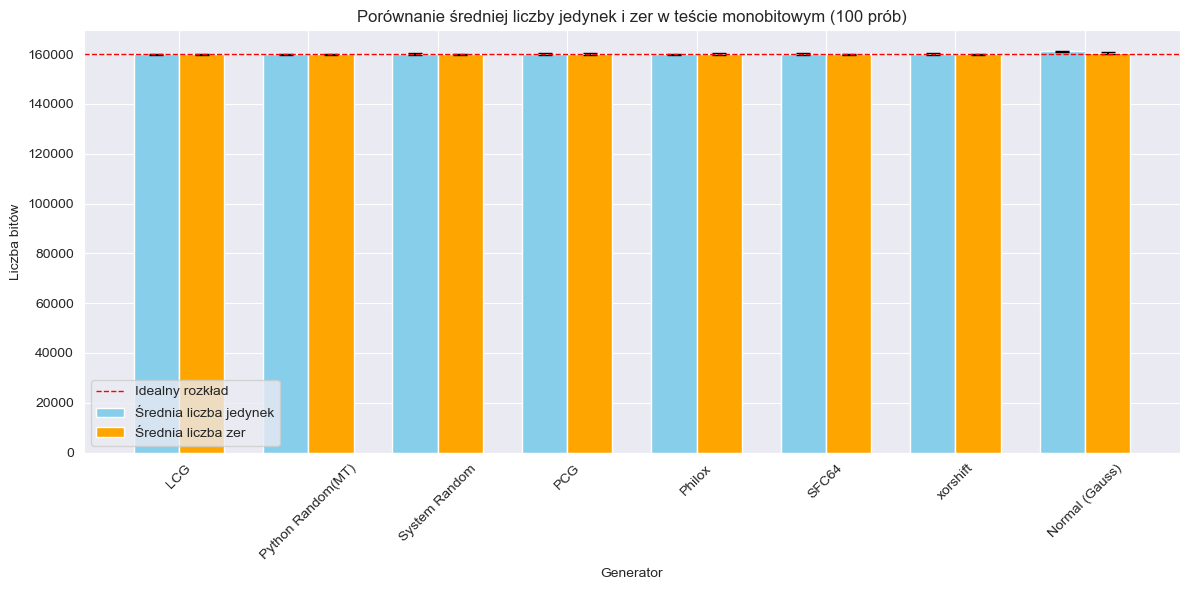

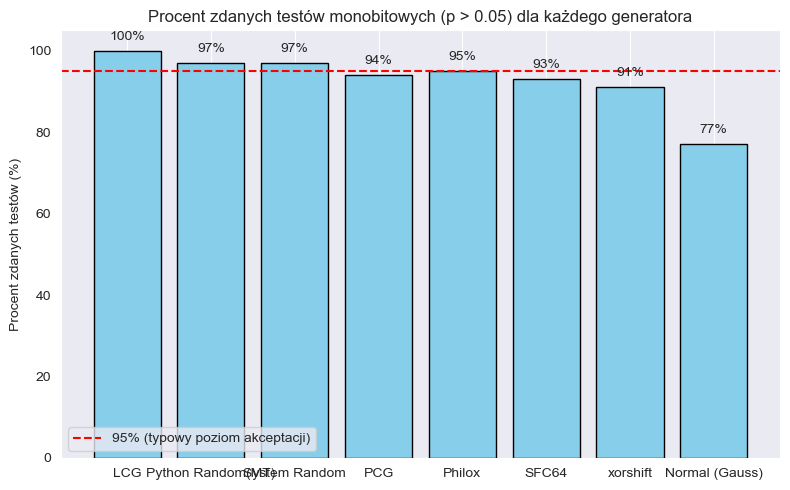

In [121]:
## Test Monobit dla 100 runów
n_runs = 100

mean_ones = {}
mean_zeros = {}
std_ones = {}
std_zeros = {}
pass_percent_mono = {}

for name, gen in generators.items():
    ones_list = []
    zeros_list = []
    passed = 0
    for _ in range(n_runs):
        data = gen()
        z_stat, p_val, ones, zeros = monobit_test(data)
        ones_list.append(ones)
        zeros_list.append(zeros)
        if p_val > 0.05:
            passed += 1
    mean_ones[name] = np.mean(ones_list)
    mean_zeros[name] = np.mean(zeros_list)
    std_ones[name] = np.std(ones_list)
    std_zeros[name] = np.std(zeros_list)
    pass_percent_mono[name] = 100 * passed / n_runs

names = list(generators.keys())
x = np.arange(len(names))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - bar_width/2, [mean_ones[n] for n in names], width=bar_width, 
        yerr=[std_ones[n] for n in names], label='Średnia liczba jedynek', color='skyblue', capsize=5)
plt.bar(x + bar_width/2, [mean_zeros[n] for n in names], width=bar_width, 
        yerr=[std_zeros[n] for n in names], label='Średnia liczba zer', color='orange', capsize=5)
plt.axhline(y=160000, color='red', linestyle='--', linewidth=1, label='Idealny rozkład')
plt.xlabel('Generator')
plt.ylabel('Liczba bitów')
plt.title('Porównanie średniej liczby jedynek i zer w teście monobitowym (100 prób)')
plt.xticks(x, names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
bars = plt.bar(names, [pass_percent_mono[n] for n in names], color='skyblue', edgecolor='black')
plt.axhline(95, color='red', linestyle='--', label='95% (typowy poziom akceptacji)')
for bar, percent in zip(bars, [pass_percent_mono[n] for n in names]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{percent:.0f}%", ha='center', va='bottom', fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Procent zdanych testów (%)")
plt.title("Procent zdanych testów monobitowych (p > 0.05) dla każdego generatora")
plt.grid(axis='y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [122]:
# max_entropy = np.log2(20)
# entropies = {name: entropy_test(data) for name, data in data_samples.items()}

# plt.figure(figsize=(8, 5))
# bars = plt.bar(entropies.keys(), entropies.values(), color='lightgreen', edgecolor='black')
# plt.axhline(max_entropy, color='red', linestyle='--', label=f'Maksymalna entropia = {max_entropy:.4f}')

# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)

# plt.title("Entropia danych dla różnych generatorów")
# plt.ylabel("Entropia (bitów)")
# plt.legend()
# plt.grid(axis='y')
# plt.tight_layout()
# plt.show()

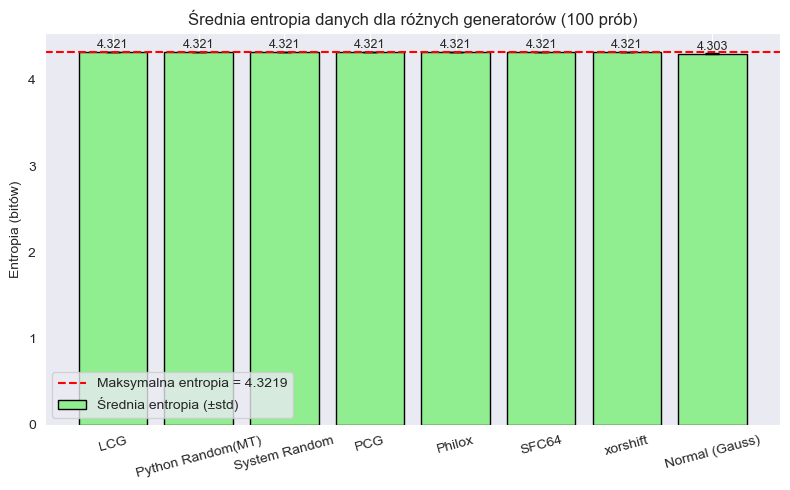

In [123]:
## Test Entropii dla 100 runów
n_runs = 100

mean_entropy = {}
std_entropy = {}

for name, gen in generators.items():
    entropy_list = []
    for _ in range(n_runs):
        data = gen()
        entropy_list.append(entropy_test(data))
    mean_entropy[name] = np.mean(entropy_list)
    std_entropy[name] = np.std(entropy_list)

names = list(generators.keys())
x = np.arange(len(names))
bar_width = 0.5
max_entropy = np.log2(20)

plt.figure(figsize=(8, 5))
bars = plt.bar(x, [mean_entropy[n] for n in names], yerr=[std_entropy[n] for n in names],
               color='lightgreen', edgecolor='black', capsize=5, label='Średnia entropia (±std)')
plt.axhline(max_entropy, color='red', linestyle='--', label=f'Maksymalna entropia = {max_entropy:.4f}')

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontsize=9)

plt.title("Średnia entropia danych dla różnych generatorów (100 prób)")
plt.ylabel("Entropia (bitów)")
plt.xticks(x, names, rotation=15)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [124]:
# assert len(lcg_numbers) == n, "Błąd: Nieprawidłowa liczba wygenerowanych liczb."
# assert all(0 <= x < 1 for x in lcg_numbers), "Błąd: Liczby nie są w zakresie (0, 1)."

# # sprawdzenie równomierności rozkładu
# max_range = 100  # liczba przedziałów dla testu chi-kwadrat
# observed, _ = np.histogram(lcg_numbers, bins=max_range, range=(0, 1))
# expected = np.full(max_range, n / max_range)
# chi2, p = stats.chisquare(observed, expected)
# print(f"Test chi-kwadrat: chi2 = {chi2:.2f}, p-value = {p:.4f}")
# assert p > 0.05, "Błąd: Rozkład nie jest równomierny (p-value < 0.05)."